# Problema 5 ML - Detección de Anomalías en Producción Ganadera y Vegetal

Objetivo: Identificar episodios atípicos de alta contaminación en granjas y detectar signos de degradación vegetal en los cultivos para activar alertas tempranas.  

**Proyecto Big Data & ML — Agricultura/Ganadería**

Este notebook implementa dos pipelines paralelos de detección de anomalías:

| Pipeline | Dataset | Objetivo | Algoritmos |
|---|---|---|---|
| **5A** — Anomalías de Emisión | `master_ganadero.csv` | Detectar picos anómalos de CH₄ | Isolation Forest · One-Class SVM |
| **5B** — Anomalías de Vegetación | `imagenes_metadata_processed.csv` | Detectar caídas bruscas de NDVI | Z-Score · Autoencoder |

> **Pseudo-etiquetas disponibles:** `flag_emision_extrema` y `flag_ndvi_anomalo` se usan para validar los modelos no supervisados (no para entrenar).


## 0. Imports y Configuración Global

In [1]:
# ── Librerías estándar y científicas ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento ──
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ── Modelos 5A ──
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# ── Métricas ──
from sklearn.metrics import (
    classification_report, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)

# ── Modelo 5B Avanzado: Autoencoder ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Configuración de visualización ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)

print("✅ Imports completados correctamente.")
print(f"   NumPy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")
print(f"   TensorFlow : {tf.__version__}")


✅ Imports completados correctamente.
   NumPy      : 2.4.3
   Pandas     : 3.0.2
   TensorFlow : 2.21.0


## PIPELINE 5A — Anomalías Tabulares de Emisión (`master_ganadero`)

### Objetivo
Identificar episodios ganaderos con emisiones de CH₄ extremadamente elevadas, correspondientes a picos reales de contaminación (fermentación entérica bovina severa).

**Decisión de diseño clave:** Los 67 registros con `flag_emision_extrema=1` identificados en el EDA son anomalías reales, **no errores**. Se conservan en el dataset completo y se usan como pseudo-etiqueta de validación.


### Fase 1: Carga de Datos y Exploración Inicial

In [2]:
# ── Carga ──
df_gan = pd.read_csv('../../data/processed/master_ganadero.csv')

print(f"Shape: {df_gan.shape}")
print(f"\nDistribución flag_emision_extrema:")
print(df_gan['flag_emision_extrema'].value_counts())
print(f"\nPorcentaje de anomalías: {df_gan['flag_emision_extrema'].mean()*100:.2f}%")
df_gan.head(3)


Shape: (600, 49)

Distribución flag_emision_extrema:
flag_emision_extrema
0    533
1     67
Name: count, dtype: int64

Porcentaje de anomalías: 11.17%


,pais,codigo_iso,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne,...,reg_rotacion_cultivos,reg_uso_agua,acuerdo_Acuerdo_Mercosur,acuerdo_Acuerdo_Paris,acuerdo_Convenio_Biodiversidad,acuerdo_ODS_2030,acuerdo_Protocolo_Kyoto,acuerdo_TLCAN,objetivo_reduccion_emisiones_pct,flag_sin_clima
0,Argentina,ARG,2011,bovino,18160590,1857394,2.355425e+09,1121740,0.062,0.1023,...,0,0,0,0,0,0,0,0,0.0,0
1,Argentina,ARG,2011,porcino,13481224,1528896,NaN,1984357,0.147,0.1134,...,0,0,0,0,0,0,0,0,0.0,0
2,Argentina,ARG,2011,avicola,979196737,1290153,NaN,10160819,0.010,0.0013,...,0,0,0,0,0,0,0,0,0.0,0


In [3]:
# ── Tipos de datos y missings ──
print("Tipos de datos:")
print(df_gan.dtypes.value_counts())
print(f"\nValores nulos por columna (solo las que tienen):")
nulls = df_gan.isnull().sum()
print(nulls[nulls > 0])


Tipos de datos:
int64      23
float64    23
str         3
Name: count, dtype: int64

Valores nulos por columna (solo las que tienen):
produccion_leche_lt           240
temperatura_promedio          100
temperatura_maxima            100
temperatura_minima            100
precipitacion_total           100
humedad_relativa_promedio     100
dias_con_heladas              100
meses_estres_hidrico          100
indice_aridez                 100
n_eventos_total_regiones      100
ev_granizo                    100
ev_helada_tardia              100
ev_incendios                  100
ev_inundacion                 100
ev_ola_calor                  100
ev_sequia_extrema             100
ev_sequia_moderada            100
ev_sequia_severa              100
ev_tormenta_severa            100
flag_anio_eventos_extremos    100
dtype: int64


### Fase 2: Preprocesamiento

In [4]:
from sklearn.impute import SimpleImputer

# ── Encoding de tipo_ganado ──
le = LabelEncoder()
df_gan['tipo_ganado_enc'] = le.fit_transform(df_gan['tipo_ganado'])
print("Codificación tipo_ganado:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase} → {i}")

# ── Feature engineering: emisiones per cápita ──
df_gan['emisiones_per_cabeza'] = (
    df_gan['emisiones_ch4_ton_co2eq'] / df_gan['cabezas_ganado'].replace(0, np.nan)
)

""""# Ratio emisiones / producción carne  (intensidad real por kg producido)
df_gan['emisiones_por_kg_carne'] = (
    df_gan['emisiones_ch4_ton_co2eq'] / df_gan['produccion_carne_ton'].replace(0, np.nan)
)

# Desviación de emisiones respecto a la media histórica del país+tipo_ganado
df_gan['emisiones_zscore_grupo'] = df_gan.groupby(['pais', 'tipo_ganado'])['emisiones_ch4_ton_co2eq'] \
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))"""

# ── Selección de features (ampliada) ──
FEATURES_5A = [
    'emisiones_ch4_ton_co2eq',
    'intensidad_emisiones',
    'eficiencia_carne',
    'cabezas_ganado',
    'produccion_carne_ton',
    'temperatura_promedio',
    'precipitacion_total',
    'humedad_relativa_promedio',
    'indice_aridez',
    'n_eventos_total_regiones',
    'tipo_ganado_enc',           # ← NUEVO: tipo de ganado codificado
    'emisiones_per_cabeza',       # ← NUEVO: emisiones per cápita
   # 'emisiones_por_kg_carne',     # ← NUEVO: intensidad real por kg producido
   # 'emisiones_zscore_grupo'      # ← NUEVO: desviación respecto a la media histórica del grupo país+tipo_ganado
]
"""
# ── Feature engineering v3 ──

# Ratio emisiones / kg de carne producido
df_gan['emisiones_por_kg_carne'] = (
    df_gan['emisiones_ch4_ton_co2eq'] /
    df_gan['produccion_carne_ton'].replace(0, np.nan)
)

# Z-Score de emisiones por país + tipo_ganado (señal relativa al contexto histórico local)
# Esta es la feature más importante: una emisión "extrema" para Brasil-bovino
# puede ser normal para España-bovino. El z-score lo corrige.
df_gan['emisiones_zscore_grupo'] = (
    df_gan.groupby(['pais', 'tipo_ganado'])['emisiones_ch4_ton_co2eq']
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
)

print("Distribución emisiones_zscore_grupo en anomalías vs normales:")
print(df_gan.groupby('flag_emision_extrema')['emisiones_zscore_grupo']
      .describe().round(3))
"""


FEATURES_5A = [f for f in FEATURES_5A if f in df_gan.columns]
print(f"\nFeatures seleccionadas ({len(FEATURES_5A)}): {FEATURES_5A}")

df_5a = df_gan[FEATURES_5A + ['flag_emision_extrema']].copy()

# ── Diagnóstico NaNs ──
nan_por_col = df_5a[FEATURES_5A].isnull().sum()
print(f"\nNaNs por feature:")
print(nan_por_col[nan_por_col > 0])

# ── Imputación con SimpleImputer (mediana) ──
X_5a_raw = df_5a[FEATURES_5A].values
y_5a = df_5a['flag_emision_extrema'].values

imputer_5a = SimpleImputer(strategy='median')
X_5a_imputed = imputer_5a.fit_transform(X_5a_raw)

assert not np.isnan(X_5a_imputed).any(), "NaNs tras SimpleImputer."
print(f"\n✅ Imputación completada. NaNs restantes: {np.isnan(X_5a_imputed).sum()}")

# ── Escalado ──
scaler_5a = StandardScaler()
X_5a_scaled = scaler_5a.fit_transform(X_5a_imputed)

assert not np.isnan(X_5a_scaled).any(), "NaNs tras escalado."

print(f"X_5a_scaled shape : {X_5a_scaled.shape}")
print(f"Anomalías reales  : {y_5a.sum()} ({y_5a.mean()*100:.2f}%)")

Codificación tipo_ganado:
  avicola → 0
  bovino → 1
  caprino → 2
  ovino → 3
  porcino → 4

Features seleccionadas (12): ['emisiones_ch4_ton_co2eq', 'intensidad_emisiones', 'eficiencia_carne', 'cabezas_ganado', 'produccion_carne_ton', 'temperatura_promedio', 'precipitacion_total', 'humedad_relativa_promedio', 'indice_aridez', 'n_eventos_total_regiones', 'tipo_ganado_enc', 'emisiones_per_cabeza']

NaNs por feature:
temperatura_promedio         100
precipitacion_total          100
humedad_relativa_promedio    100
indice_aridez                100
n_eventos_total_regiones     100
dtype: int64

✅ Imputación completada. NaNs restantes: 0
X_5a_scaled shape : (600, 12)
Anomalías reales  : 67 (11.17%)


  log1p aplicado a 'emisiones_ch4_ton_co2eq'
  log1p aplicado a 'cabezas_ganado'
  log1p aplicado a 'produccion_carne_ton'


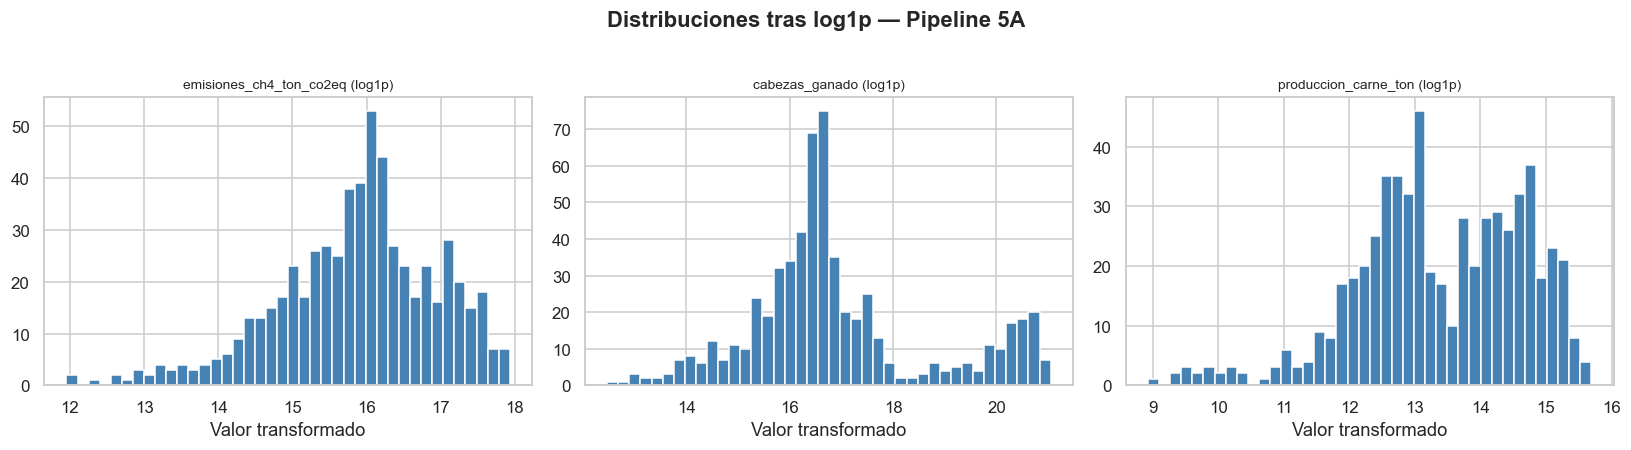

✅ Transformación log1p aplicada.


In [5]:
# ── Transformación log1p para estabilizar varianza (indicado por EDA) ──
# Variables de volumen con distribución muy sesgada
LOG_COLS = ['emisiones_ch4_ton_co2eq', 'cabezas_ganado', 'produccion_carne_ton']
LOG_COLS = [c for c in LOG_COLS if c in FEATURES_5A]

for col in LOG_COLS:
    df_5a[col] = np.log1p(df_5a[col])
    print(f"  log1p aplicado a '{col}'")

# Visualización de distribución antes/después
fig, axes = plt.subplots(1, len(LOG_COLS), figsize=(5*len(LOG_COLS), 4))
if len(LOG_COLS) == 1:
    axes = [axes]
for ax, col in zip(axes, LOG_COLS):
    df_5a[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} (log1p)', fontsize=9)
    ax.set_xlabel('Valor transformado')
plt.suptitle('Distribuciones tras log1p — Pipeline 5A', y=1.02, fontweight='bold')
plt.tight_layout()
#plt.savefig('5a_distribuciones_log1p.png', bbox_inches='tight')
plt.show()
print("✅ Transformación log1p aplicada.")


In [6]:
from sklearn.impute import SimpleImputer

# ── Diagnóstico: identificar qué columnas tienen NaNs ──
nan_por_col = df_5a[FEATURES_5A].isnull().sum()
print("NaNs por feature ANTES de imputar:")
print(nan_por_col[nan_por_col > 0])

# ── Imputación robusta con mediana (directamente sobre la matriz numpy) ──
X_5a_raw = df_5a[FEATURES_5A].values
y_5a = df_5a['flag_emision_extrema'].values  # pseudo-etiqueta (solo para validación)

imputer_5a = SimpleImputer(strategy='median')
X_5a_imputed = imputer_5a.fit_transform(X_5a_raw)

# Verificación intermedia
assert not np.isnan(X_5a_imputed).any(), "Aún hay NaNs tras SimpleImputer."
print(f"\n✅ Imputación completada. NaNs restantes: {np.isnan(X_5a_imputed).sum()}")

# ── Escalado estándar (sobre datos ya limpios) ──
scaler_5a = StandardScaler()
X_5a_scaled = scaler_5a.fit_transform(X_5a_imputed)

# Verificación final
assert not np.isnan(X_5a_scaled).any(), "NaNs tras escalado — revisar pipeline."

print(f"X_5a_scaled shape : {X_5a_scaled.shape}")
print(f"Anomalías reales  : {y_5a.sum()} ({y_5a.mean()*100:.2f}%)")

NaNs por feature ANTES de imputar:
temperatura_promedio         100
precipitacion_total          100
humedad_relativa_promedio    100
indice_aridez                100
n_eventos_total_regiones     100
dtype: int64

✅ Imputación completada. NaNs restantes: 0
X_5a_scaled shape : (600, 12)
Anomalías reales  : 67 (11.17%)


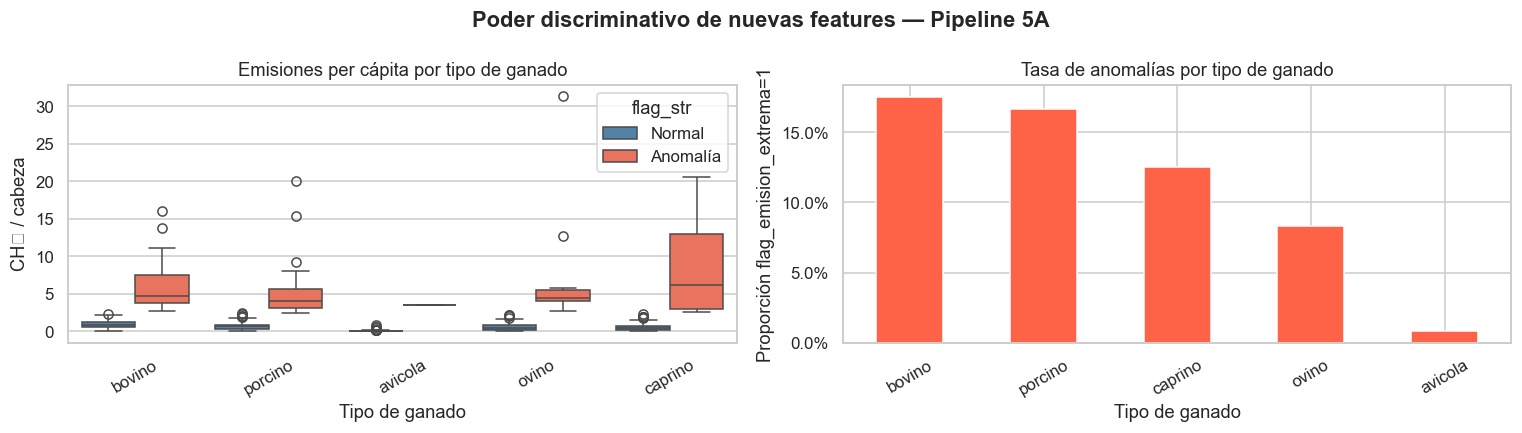

In [7]:
# ── Distribución de emisiones_per_cabeza por tipo de ganado ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot emisiones per cápita por tipo ganado coloreado por anomalía
df_gan['flag_str'] = df_gan['flag_emision_extrema'].map({0: 'Normal', 1: 'Anomalía'})
sns.boxplot(data=df_gan, x='tipo_ganado', y='emisiones_per_cabeza',
            hue='flag_str', palette={'Normal': 'steelblue', 'Anomalía': 'tomato'},
            ax=axes[0])
axes[0].set_title('Emisiones per cápita por tipo de ganado')
axes[0].set_xlabel('Tipo de ganado')
axes[0].set_ylabel('CH₄ / cabeza')
axes[0].tick_params(axis='x', rotation=30)

# Proporción de anomalías por tipo de ganado
anom_rate = df_gan.groupby('tipo_ganado')['flag_emision_extrema'].mean().sort_values(ascending=False)
anom_rate.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Tasa de anomalías por tipo de ganado')
axes[1].set_ylabel('Proporción flag_emision_extrema=1')
axes[1].set_xlabel('Tipo de ganado')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Poder discriminativo de nuevas features — Pipeline 5A', fontweight='bold')
plt.tight_layout()
#plt.savefig('5a_nuevas_features_eda.png', bbox_inches='tight')
plt.show()

### Fase3: Modelo Baseline: Isolation Forest

**¿Por qué Isolation Forest?**  
Construye árboles de decisión aleatorios: los puntos que se aíslan en pocas divisiones son estadísticamente raros. Es especialmente efectivo cuando las anomalías son una minoría pequeña (aquí ~3–5%) y no requiere asumir ninguna distribución.

**Parámetro clave — `contamination`:** Fracción esperada de anomalías en el dataset. Se fija a partir del porcentaje real de `flag_emision_extrema=1`.


In [8]:
# ── Calcular tasa de contaminación real ──
contamination_5a = y_5a.mean()
print(f"Tasa de contaminación (flag_emision_extrema): {contamination_5a:.4f} ({contamination_5a*100:.2f}%)")

# ── Entrenamiento ──
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_5a,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_5a_scaled)

# Isolation Forest: -1 = anomalía, 1 = normal → convertir a 0/1
y_pred_if = (iso_forest.predict(X_5a_scaled) == -1).astype(int)
anomaly_scores_if = -iso_forest.score_samples(X_5a_scaled)  # mayor = más anómalo

print(f"\nAnomalías detectadas por IF: {y_pred_if.sum()} ({y_pred_if.mean()*100:.2f}%)")


Tasa de contaminación (flag_emision_extrema): 0.1117 (11.17%)

Anomalías detectadas por IF: 67 (11.17%)


In [9]:
# ── Evaluación con pseudo-etiquetas ──
print("="*55)
print("ISOLATION FOREST — Evaluación con flag_emision_extrema")
print("="*55)
print(classification_report(y_5a, y_pred_if, target_names=['Normal', 'Anomalía']))

f1_if = f1_score(y_5a, y_pred_if)
print(f"F1-Score (anomalías): {f1_if:.4f}")


ISOLATION FOREST — Evaluación con flag_emision_extrema
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       533
    Anomalía       0.61      0.61      0.61        67

    accuracy                           0.91       600
   macro avg       0.78      0.78      0.78       600
weighted avg       0.91      0.91      0.91       600

F1-Score (anomalías): 0.6119


In [10]:
# ── Precision@k ──
def precision_at_k(y_true, scores, k=100):
    """¿De las top-k anomalías detectadas por score, cuántas son reales?"""
    top_k_idx = np.argsort(scores)[::-1][:k]
    tp = y_true[top_k_idx].sum()
    return tp / k, tp

p_at_k_if, tp_if = precision_at_k(y_5a, anomaly_scores_if, k=100)
print(f"Precision@100 (IF) : {p_at_k_if:.4f}  ({tp_if} anomalías reales en top 100)")


Precision@100 (IF) : 0.4800  (48 anomalías reales en top 100)


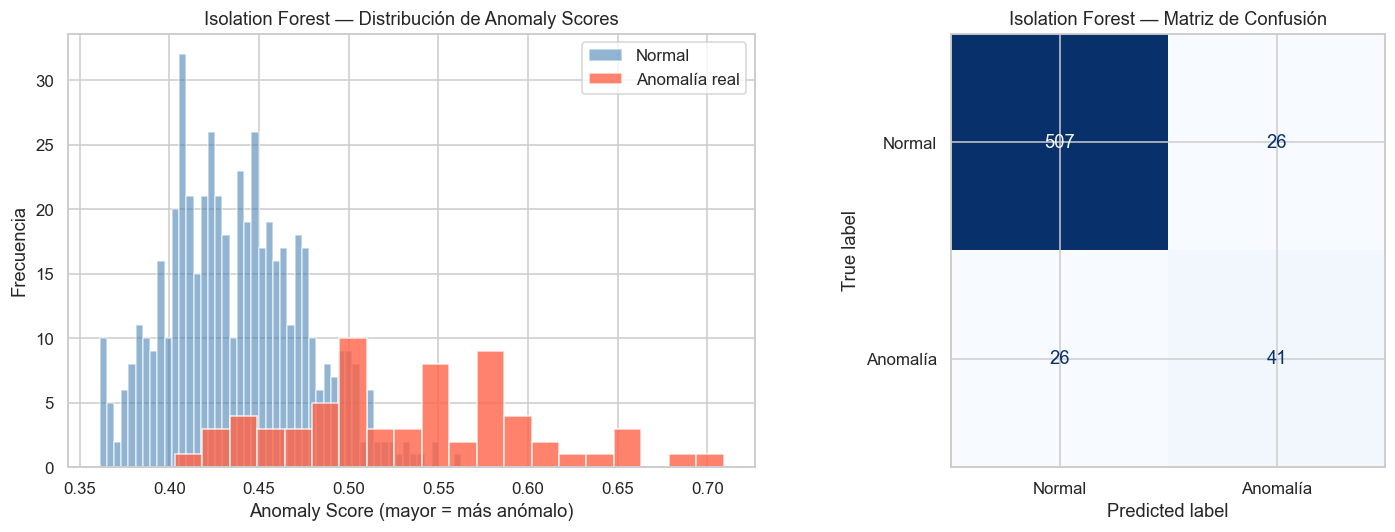

In [11]:
# ── Visualización: Anomaly Score Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de scores
axes[0].hist(anomaly_scores_if[y_5a == 0], bins=50, alpha=0.6, label='Normal', color='steelblue')
axes[0].hist(anomaly_scores_if[y_5a == 1], bins=20, alpha=0.8, label='Anomalía real', color='tomato')
axes[0].set_title('Isolation Forest — Distribución de Anomaly Scores')
axes[0].set_xlabel('Anomaly Score (mayor = más anómalo)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Confusion Matrix
cm_if = confusion_matrix(y_5a, y_pred_if)
ConfusionMatrixDisplay(cm_if, display_labels=['Normal', 'Anomalía']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Isolation Forest — Matriz de Confusión')

plt.tight_layout()
#plt.savefig('5a_isolation_forest_eval.png', bbox_inches='tight')
plt.show()


### Fase 4: — Modelo Alternativo: One-Class SVM

**¿Por qué One-Class SVM?**  
Aprende la "frontera" del comportamiento ganadero normal en un espacio de características de alta dimensión (mediante el kernel RBF). Todo lo que quede fuera de esa frontera se clasifica como anomalía. Complementa al Isolation Forest porque captura la estructura geométrica multivariante del espacio normal.

> **Nota de escala:** One-Class SVM es más lento que Isolation Forest. Se puede submuestrear el conjunto de entrenamiento si el dataset es grande.


In [12]:
import numpy as np
from sklearn.impute import SimpleImputer

# ── Diagnóstico rápido ──
nan_mask = np.isnan(X_5a_scaled)
print(f"NaNs en X_5a_scaled: {nan_mask.sum()} (en {nan_mask.any(axis=0).sum()} features)")

# ── Imputación de seguridad con mediana (robusto ante outliers) ──
imputer_svm = SimpleImputer(strategy='median')
X_5a_clean = imputer_svm.fit_transform(X_5a_scaled)

print(f"NaNs tras imputación: {np.isnan(X_5a_clean).sum()}")

# ── Entrenamiento One-Class SVM ──
oc_svm = OneClassSVM(
    kernel='rbf',
    nu=contamination_5a,
    gamma='scale'
)
oc_svm.fit(X_5a_clean)

# -1 = anomalía, 1 = normal
y_pred_svm = (oc_svm.predict(X_5a_clean) == -1).astype(int)
anomaly_scores_svm = -oc_svm.score_samples(X_5a_clean)

print(f"Anomalías detectadas por OC-SVM: {y_pred_svm.sum()} ({y_pred_svm.mean()*100:.2f}%)")

NaNs en X_5a_scaled: 0 (en 0 features)
NaNs tras imputación: 0
Anomalías detectadas por OC-SVM: 71 (11.83%)


In [13]:
# ── Evaluación OC-SVM ──
print("="*55)
print("ONE-CLASS SVM — Evaluación con flag_emision_extrema")
print("="*55)
print(classification_report(y_5a, y_pred_svm, target_names=['Normal', 'Anomalía']))

f1_svm = f1_score(y_5a, y_pred_svm)
p_at_k_svm, tp_svm = precision_at_k(y_5a, anomaly_scores_svm, k=100)

print(f"F1-Score (anomalías)  : {f1_svm:.4f}")
print(f"Precision@100 (SVM)   : {p_at_k_svm:.4f}  ({tp_svm} anomalías reales en top 100)")


ONE-CLASS SVM — Evaluación con flag_emision_extrema
              precision    recall  f1-score   support

      Normal       0.93      0.92      0.93       533
    Anomalía       0.42      0.45      0.43        67

    accuracy                           0.87       600
   macro avg       0.68      0.69      0.68       600
weighted avg       0.87      0.87      0.87       600

F1-Score (anomalías)  : 0.4348
Precision@100 (SVM)   : 0.3500  (35 anomalías reales en top 100)


### Fase 5: Comparativa de Modelos y Conclusiones Pipeline 5A

In [14]:
# ── Tabla comparativa ──
results_5a = pd.DataFrame({
    'Modelo': ['Isolation Forest', 'One-Class SVM'],
    'F1-Score': [f1_if, f1_svm],
    'Precision@100': [p_at_k_if, p_at_k_svm],
    'Anomalías detectadas': [y_pred_if.sum(), y_pred_svm.sum()],
    'Anomalías reales (67)': [67, 67]
})
print(results_5a.to_string(index=False))
print()

# ── Mejor modelo ──
best_5a = results_5a.loc[results_5a['F1-Score'].idxmax(), 'Modelo']
print(f"✅ Mejor modelo Pipeline 5A: {best_5a}")


          Modelo  F1-Score  Precision@100  Anomalías detectadas  Anomalías reales (67)
Isolation Forest  0.611940           0.48                    67                     67
   One-Class SVM  0.434783           0.35                    71                     67

✅ Mejor modelo Pipeline 5A: Isolation Forest


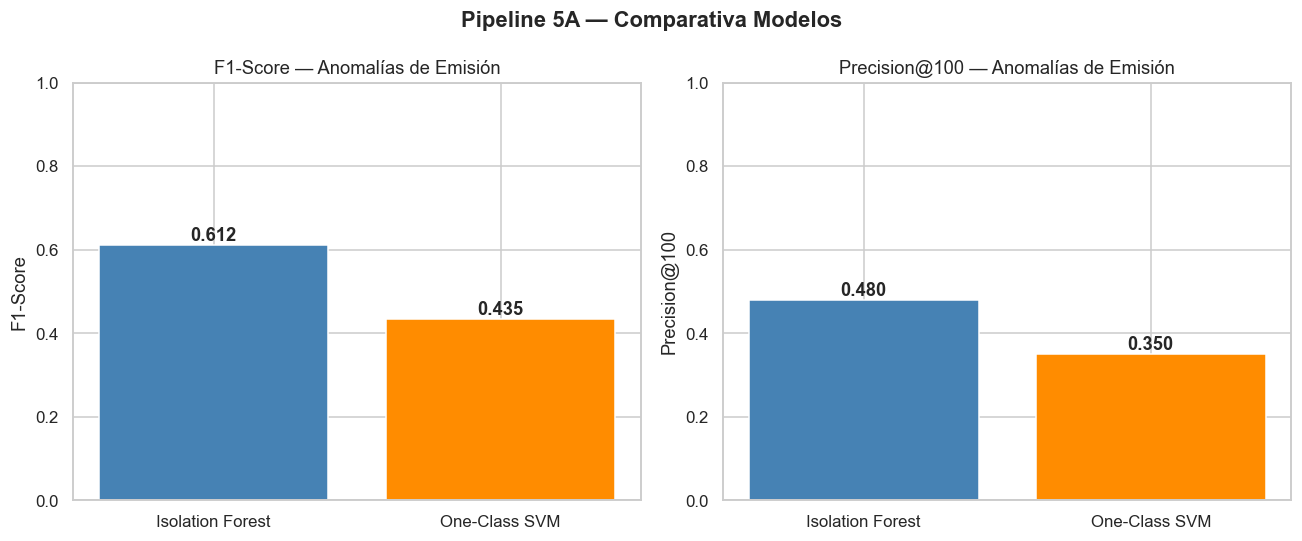

In [15]:
# ── Visualización comparativa ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Isolation Forest', 'One-Class SVM']
f1s = [f1_if, f1_svm]
pks = [p_at_k_if, p_at_k_svm]
colors = ['steelblue', 'darkorange']

axes[0].bar(models, f1s, color=colors, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('F1-Score — Anomalías de Emisión')
axes[0].set_ylabel('F1-Score')
for i, v in enumerate(f1s):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(models, pks, color=colors, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('Precision@100 — Anomalías de Emisión')
axes[1].set_ylabel('Precision@100')
for i, v in enumerate(pks):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Pipeline 5A — Comparativa Modelos', fontweight='bold')
plt.tight_layout()
#plt.savefig('5a_comparativa_modelos.png', bbox_inches='tight')
plt.show()


In [16]:
# GUARDAR MODELO Y PREPROCESADORES PARA PRODUCCIÓN

import os
import joblib

# ── Guardar Isolation Forest (modelo de producción) ──
joblib.dump(iso_forest, '../../models/P5/pipeline_5a_isolation_forest.joblib')

# ── Guardar preprocesadores (imprescindible para producción) ──
joblib.dump(imputer_5a,  '../../models/P5/pipeline_5a_imputer.joblib')
joblib.dump(scaler_5a,   '../../models/P5/pipeline_5a_scaler.joblib')
joblib.dump(le,          '../../models/P5/pipeline_5a_label_encoder_tipo_ganado.joblib')

# ── Guardar lista de features (para garantizar el orden en inferencia) ──
joblib.dump(FEATURES_5A, '../../models/P5/pipeline_5a_features.joblib')

print("✅ Pipeline 5A guardado en ../../models/P5/pipeline_5a/")
print(f"   • isolation_forest.joblib")
print(f"   • imputer.joblib")
print(f"   • scaler.joblib")
print(f"   • label_encoder_tipo_ganado.joblib")
print(f"   • features.joblib")

✅ Pipeline 5A guardado en ../../models/P5/pipeline_5a/
   • isolation_forest.joblib
   • imputer.joblib
   • scaler.joblib
   • label_encoder_tipo_ganado.joblib
   • features.joblib


## PIPELINE 5B — Anomalías Espaciales de Vegetación (`imagenes_metadata`)

### Objetivo
Detectar caídas bruscas del índice NDVI que indiquen posibles sequías, plagas o degradación vegetal en zonas agrícolas.

### Restricción documentada — Años futuros


In [17]:
# ════════════════════════════════════════════════════════
# NOTA METODOLÓGICA — RESTRICCIÓN CRÍTICA (DOCUMENTAR EN MEMORIA)
# ════════════════════════════════════════════════════════
#
# El dataset imagenes_metadata_processed.csv contiene registros con
# años desde 2020 hasta 2033. Los años 2027-2033 son FUTUROS y no
# pueden corresponder a imágenes satelitales reales.
#
# Decisión adoptada: Se asume que son PROYECCIONES PREDICTIVAS de la
# fuente de datos original. Dado el tamaño reducido del dataset, se
# opta por conservarlos como datos válidos en lugar de descartarlos.
#
# Este supuesto DEBE mencionarse explícitamente en la memoria del
# proyecto y en cualquier interpretación de resultados.
# ════════════════════════════════════════════════════════
print(" Restricción documentada: registros 2027-2033 tratados como proyecciones predictivas.")


 Restricción documentada: registros 2027-2033 tratados como proyecciones predictivas.


### Fase1: Carga de Datos y Filtrado Geográfico

In [18]:
# ── Carga ──
df_img = pd.read_csv('../../data/processed/imagenes_metadata_processed.csv')

print(f"Shape total: {df_img.shape}")
print(f"\nDistribución por país:")
print(df_img['pais'].value_counts())
print(f"\nRango de años: {df_img['anio'].min()} – {df_img['anio'].max()}")
print(f"\nDistribución flag_ndvi_anomalo:")
print(df_img['flag_ndvi_anomalo'].value_counts())


Shape total: (250, 23)

Distribución por país:
pais
Argentina         41
Estados Unidos    39
Alemania          32
Francia           31
China             31
India             29
Australia         25
Brasil            22
Name: count, dtype: int64

Rango de años: 2020 – 2033

Distribución flag_ndvi_anomalo:
flag_ndvi_anomalo
0    225
1     25
Name: count, dtype: int64


In [19]:
# ── Filtro: Australia e India (mayor fiabilidad según EDA: 80% y 72%) ──
PAISES_FIABLES = ['Australia', 'India']
df_5b = df_img[df_img['pais'].isin(PAISES_FIABLES)].copy()

print(f"Registros tras filtro geográfico: {len(df_5b)}")
print(f"\nDistribución por país:")
print(df_5b['pais'].value_counts())
print(f"\nAnomálias NDVI en subconjunto:")
print(df_5b['flag_ndvi_anomalo'].value_counts())


Registros tras filtro geográfico: 54

Distribución por país:
pais
India        29
Australia    25
Name: count, dtype: int64

Anomálias NDVI en subconjunto:
flag_ndvi_anomalo
0    45
1     9
Name: count, dtype: int64


### Fase 2: Preprocesamiento Pipeline 5B

In [20]:
# ── Features para detección de anomalías de vegetación ──
FEATURES_5B = [
    'indice_ndvi_promedio',
    'indice_ndvi_min',
    'indice_ndvi_max',
    'indice_evi',
    'humedad_suelo_estimada',
    'cobertura_nubes',
    'calidad_imagen_num',
    'mes'                    # estacionalidad
]

FEATURES_5B = [f for f in FEATURES_5B if f in df_5b.columns]
print(f"Features seleccionadas ({len(FEATURES_5B)}): {FEATURES_5B}")

# ── Imputación ──
for col in FEATURES_5B:
    if df_5b[col].isnull().sum() > 0:
        df_5b[col].fillna(df_5b[col].median(), inplace=True)
        print(f"  Imputado '{col}'")

X_5b = df_5b[FEATURES_5B].values
y_5b = df_5b['flag_ndvi_anomalo'].values

print(f"\nX_5b shape : {X_5b.shape}")
print(f"Anomalías  : {y_5b.sum()} ({y_5b.mean()*100:.2f}%)")


Features seleccionadas (8): ['indice_ndvi_promedio', 'indice_ndvi_min', 'indice_ndvi_max', 'indice_evi', 'humedad_suelo_estimada', 'cobertura_nubes', 'calidad_imagen_num', 'mes']

X_5b shape : (54, 8)
Anomalías  : 9 (16.67%)


✅ Datos escalados (StandardScaler).


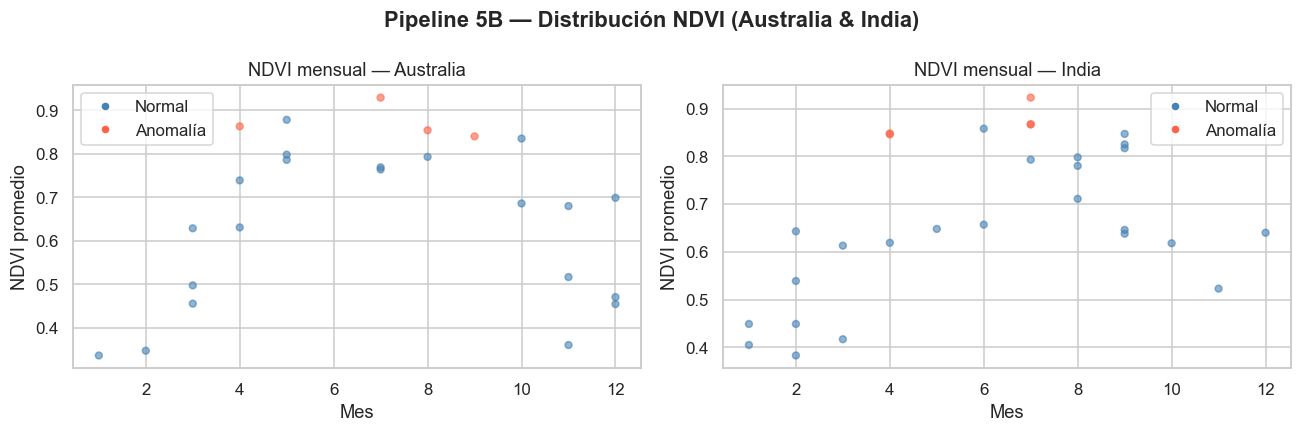

In [21]:
# ── Escalado ──
scaler_5b = StandardScaler()
X_5b_scaled = scaler_5b.fit_transform(X_5b)
print("✅ Datos escalados (StandardScaler).")

# ── Visualización NDVI por país ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pais in zip(axes, PAISES_FIABLES):
    subset = df_5b[df_5b['pais'] == pais]
    ax.scatter(subset['mes'], subset['indice_ndvi_promedio'],
               c=subset['flag_ndvi_anomalo'].map({0: 'steelblue', 1: 'tomato'}),
               alpha=0.6, s=20)
    ax.set_title(f'NDVI mensual — {pais}')
    ax.set_xlabel('Mes')
    ax.set_ylabel('NDVI promedio')
    from matplotlib.lines import Line2D
    legend_els = [Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',label='Normal'),
                  Line2D([0],[0],marker='o',color='w',markerfacecolor='tomato',label='Anomalía')]
    ax.legend(handles=legend_els)

plt.suptitle('Pipeline 5B — Distribución NDVI (Australia & India)', fontweight='bold')
plt.tight_layout()
#plt.savefig('5b_ndvi_scatter.png', bbox_inches='tight')
plt.show()


### Fase3: Modelo Baseline: Umbral Estadístico (Z-Score sobre NDVI)

**¿Por qué Z-Score como baseline?**  
Es el método más interpretable: si el NDVI de una imagen cae más de **N desviaciones estándar** por debajo de la media histórica de ese país, se considera anómalo. Sirve como cota inferior de rendimiento que los modelos más complejos deben superar.


In [22]:
# ── Z-Score sobre indice_ndvi_promedio por país ──
def zscore_anomaly(df, ndvi_col='indice_ndvi_promedio', group_col='pais', threshold=2.0):
    """
    Detecta anomalías NDVI usando Z-Score por grupo.
    threshold: número de desviaciones estándar (|z| > threshold → anomalía)
    """
    df = df.copy()
    df['ndvi_mean'] = df.groupby(group_col)[ndvi_col].transform('mean')
    df['ndvi_std']  = df.groupby(group_col)[ndvi_col].transform('std')
    df['z_score']   = (df[ndvi_col] - df['ndvi_mean']) / df['ndvi_std']
    df['pred_zscore'] = (df['z_score'].abs() > threshold).astype(int)
    return df

# Probar varios umbrales
resultados_z = []
for threshold in [1.5, 2.0, 2.5, 3.0]:
    df_z = zscore_anomaly(df_5b, threshold=threshold)
    y_pred_z = df_z['pred_zscore'].values
    f1_z = f1_score(y_5b, y_pred_z, zero_division=0)
    p_k_z, _ = precision_at_k(y_5b, df_z['z_score'].abs().values, k=min(100, len(y_5b)))
    resultados_z.append({'Threshold': threshold, 'F1-Score': f1_z, 'Precision@k': p_k_z,
                         'Detectadas': y_pred_z.sum()})

df_z_results = pd.DataFrame(resultados_z)
print("Z-Score — Búsqueda de umbral óptimo:")
print(df_z_results.to_string(index=False))

best_threshold = df_z_results.loc[df_z_results['F1-Score'].idxmax(), 'Threshold']
print(f"\n✅ Mejor umbral Z-Score: {best_threshold}")


Z-Score — Búsqueda de umbral óptimo:
 Threshold  F1-Score  Precision@k  Detectadas
       1.5     0.125     0.166667           7
       2.0     0.000     0.166667           0
       2.5     0.000     0.166667           0
       3.0     0.000     0.166667           0

✅ Mejor umbral Z-Score: 1.5


In [23]:
# ── Aplicar mejor umbral ──
df_z_best = zscore_anomaly(df_5b, threshold=best_threshold)
y_pred_zscore = df_z_best['pred_zscore'].values
anomaly_scores_zscore = df_z_best['z_score'].abs().values

print("="*55)
print(f"Z-SCORE (threshold={best_threshold}) — Evaluación")
print("="*55)
print(classification_report(y_5b, y_pred_zscore, target_names=['Normal', 'Anomalía']))

f1_zscore = f1_score(y_5b, y_pred_zscore, zero_division=0)
p_at_k_zscore, tp_zscore = precision_at_k(y_5b, anomaly_scores_zscore, k=min(100, len(y_5b)))
print(f"F1-Score    : {f1_zscore:.4f}")
print(f"Precision@k : {p_at_k_zscore:.4f}  ({tp_zscore} anomalías reales)")


Z-SCORE (threshold=1.5) — Evaluación
              precision    recall  f1-score   support

      Normal       0.83      0.87      0.85        45
    Anomalía       0.14      0.11      0.12         9

    accuracy                           0.74        54
   macro avg       0.49      0.49      0.49        54
weighted avg       0.72      0.74      0.73        54

F1-Score    : 0.1250
Precision@k : 0.1667  (9 anomalías reales)


### Fase 4: Modelo Avanzado: Autoencoder (Red Neuronal)

**¿Por qué Autoencoder?**  
El Autoencoder se entrena para **reconstruir las características de imágenes "sanas"**. Cuando se le presenta una imagen con vegetación degradada, el error de reconstrucción (`reconstruction_error`) será alto, ya que el modelo no "conoce" ese patrón. Esa diferencia actúa como señal de alerta.

**Arquitectura:** Encoder → Espacio latente comprimido → Decoder. El error de reconstrucción (MSE) es el score de anomalía.


In [24]:
# ── Construcción del Autoencoder ──
input_dim = X_5b_scaled.shape[1]
encoding_dim = max(2, input_dim // 3)  # cuello de botella

# Encoder
inputs = keras.Input(shape=(input_dim,), name='input')
encoded = layers.Dense(input_dim * 2, activation='relu')(inputs)
encoded = layers.BatchNormalization()(encoded)
encoded = layers.Dropout(0.1)(encoded)
encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(encoded)

# Decoder
decoded = layers.Dense(input_dim * 2, activation='relu')(encoded)
decoded = layers.BatchNormalization()(decoded)
decoded = layers.Dense(input_dim, activation='linear', name='output')(decoded)

autoencoder = keras.Model(inputs, decoded, name='Autoencoder_5B')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "Autoencoder_5B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 490 (1.91 KB)

 Trainable params: 426 (1.66 KB)

 Non-trainable params: 64 (256.00 B)

Muestras de entrenamiento (normales): 45


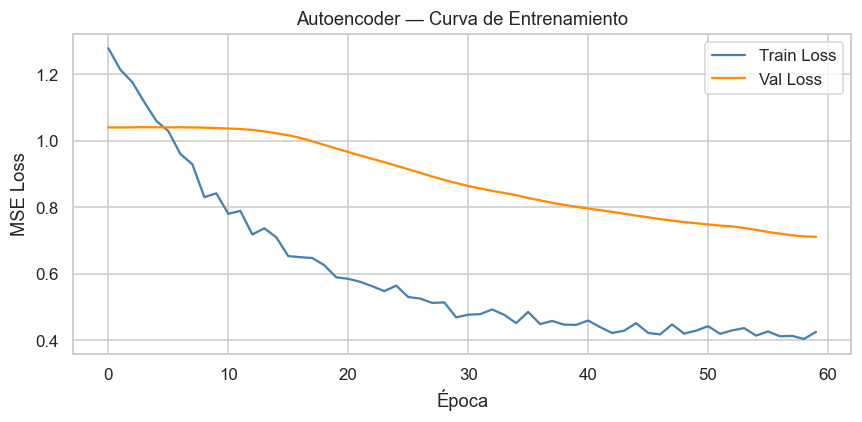

✅ Entrenamiento completado.


In [25]:
# ── Entrenamiento: SOLO con muestras normales ──
# El autoencoder aprende a reconstruir datos normales; las anomalías tendrán alto error
X_train_ae = X_5b_scaled[y_5b == 0]
print(f"Muestras de entrenamiento (normales): {X_train_ae.shape[0]}")

history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=60,
    batch_size=16,
    validation_split=0.15,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
    ],
    verbose=0
)

# Curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='darkorange')
plt.title('Autoencoder — Curva de Entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
#plt.savefig('5b_autoencoder_training.png', bbox_inches='tight')
plt.show()
print("✅ Entrenamiento completado.")


In [26]:
# ── Calcular Reconstruction Error (Anomaly Score) ──
X_reconstructed = autoencoder.predict(X_5b_scaled, verbose=0)
reconstruction_errors = np.mean(np.square(X_5b_scaled - X_reconstructed), axis=1)

# ── Umbral: percentil (1 - contamination) sobre errores de muestras normales ──
contamination_5b = y_5b.mean()
threshold_ae = np.percentile(reconstruction_errors[y_5b == 0], (1 - contamination_5b) * 100)
print(f"Umbral Autoencoder (percentil {(1-contamination_5b)*100:.1f}% de normales): {threshold_ae:.6f}")

y_pred_ae = (reconstruction_errors > threshold_ae).astype(int)
print(f"Anomalías detectadas: {y_pred_ae.sum()} ({y_pred_ae.mean()*100:.2f}%)")


Umbral Autoencoder (percentil 83.3% de normales): 0.803491
Anomalías detectadas: 10 (18.52%)


In [27]:
# ── Evaluación Autoencoder ──
print("="*55)
print("AUTOENCODER — Evaluación con flag_ndvi_anomalo")
print("="*55)
print(classification_report(y_5b, y_pred_ae, target_names=['Normal', 'Anomalía']))

f1_ae = f1_score(y_5b, y_pred_ae, zero_division=0)
p_at_k_ae, tp_ae = precision_at_k(y_5b, reconstruction_errors, k=min(100, len(y_5b)))

print(f"F1-Score    : {f1_ae:.4f}")
print(f"Precision@k : {p_at_k_ae:.4f}  ({tp_ae} anomalías reales)")


AUTOENCODER — Evaluación con flag_ndvi_anomalo
              precision    recall  f1-score   support

      Normal       0.84      0.82      0.83        45
    Anomalía       0.20      0.22      0.21         9

    accuracy                           0.72        54
   macro avg       0.52      0.52      0.52        54
weighted avg       0.73      0.72      0.73        54

F1-Score    : 0.2105
Precision@k : 0.1667  (9 anomalías reales)


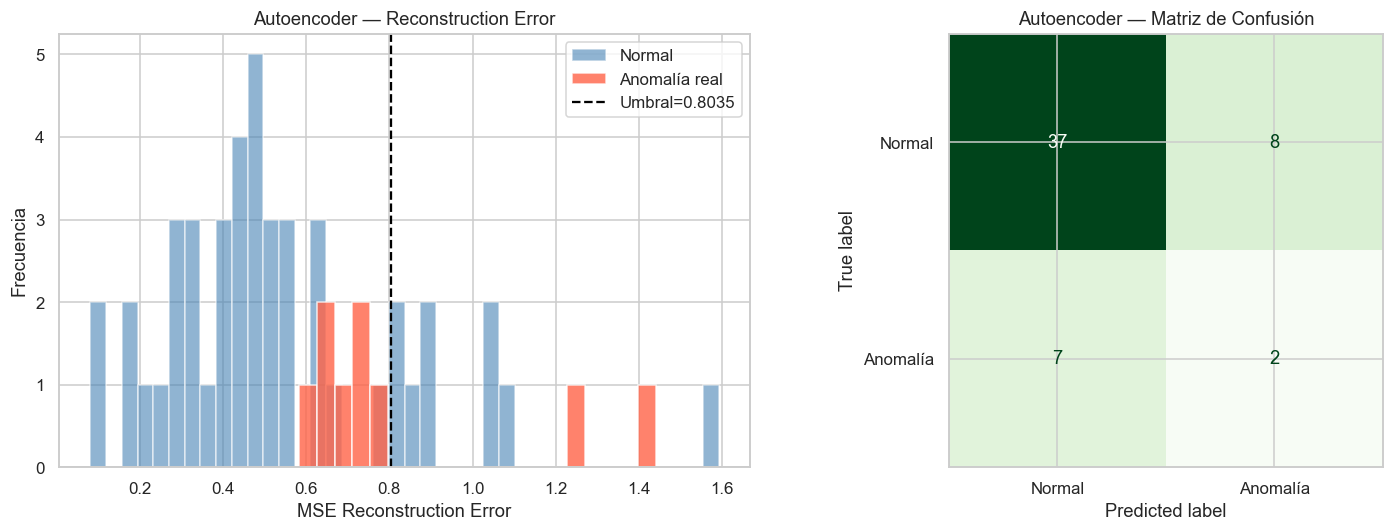

In [28]:
# ── Visualización del Reconstruction Error ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(reconstruction_errors[y_5b == 0], bins=40, alpha=0.6, label='Normal', color='steelblue')
axes[0].hist(reconstruction_errors[y_5b == 1], bins=20, alpha=0.8, label='Anomalía real', color='tomato')
axes[0].axvline(threshold_ae, color='black', linestyle='--', label=f'Umbral={threshold_ae:.4f}')
axes[0].set_title('Autoencoder — Reconstruction Error')
axes[0].set_xlabel('MSE Reconstruction Error')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

cm_ae = confusion_matrix(y_5b, y_pred_ae)
ConfusionMatrixDisplay(cm_ae, display_labels=['Normal', 'Anomalía']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Autoencoder — Matriz de Confusión')

plt.tight_layout()
#plt.savefig('5b_autoencoder_eval.png', bbox_inches='tight')
plt.show()


### Fase 5: Comparativa de Modelos y Conclusiones Pipeline 5B

In [29]:
# ── Tabla comparativa ──
results_5b = pd.DataFrame({
    'Modelo': ['Z-Score (baseline)', 'Autoencoder'],
    'F1-Score': [f1_zscore, f1_ae],
    'Precision@k': [p_at_k_zscore, p_at_k_ae],
    'Anomalías detectadas': [y_pred_zscore.sum(), y_pred_ae.sum()]
})
print("Pipeline 5B — Comparativa de Modelos:")
print(results_5b.to_string(index=False))

best_5b = results_5b.loc[results_5b['F1-Score'].idxmax(), 'Modelo']
print(f"\n✅ Mejor modelo Pipeline 5B: {best_5b}")


Pipeline 5B — Comparativa de Modelos:
            Modelo  F1-Score  Precision@k  Anomalías detectadas
Z-Score (baseline)  0.125000     0.166667                     7
       Autoencoder  0.210526     0.166667                    10

✅ Mejor modelo Pipeline 5B: Autoencoder


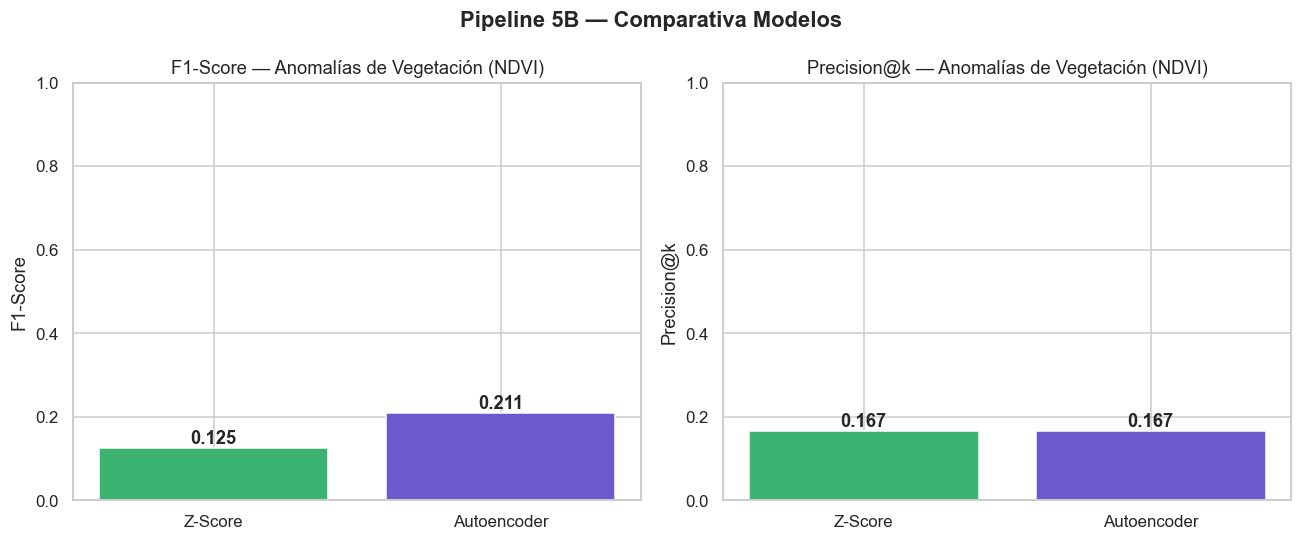

In [30]:
# ── Visualización comparativa ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_5b = ['Z-Score', 'Autoencoder']
f1s_5b = [f1_zscore, f1_ae]
pks_5b = [p_at_k_zscore, p_at_k_ae]
colors_5b = ['mediumseagreen', 'slateblue']

axes[0].bar(models_5b, f1s_5b, color=colors_5b, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('F1-Score — Anomalías de Vegetación (NDVI)')
axes[0].set_ylabel('F1-Score')
for i, v in enumerate(f1s_5b):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(models_5b, pks_5b, color=colors_5b, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('Precision@k — Anomalías de Vegetación (NDVI)')
axes[1].set_ylabel('Precision@k')
for i, v in enumerate(pks_5b):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Pipeline 5B — Comparativa Modelos', fontweight='bold')
plt.tight_layout()
#plt.savefig('5b_comparativa_modelos.png', bbox_inches='tight')
plt.show()


In [31]:
# GUARDAR MODELO Y PREPROCESADORES PARA PRODUCCIÓN

# ── Guardar Autoencoder (modelo de producción) ──
autoencoder.save('../../models/P5/pipeline_5b_autoencoder.keras')

# ── Guardar preprocesadores ──
joblib.dump(scaler_5b,        '../../models/P5/pipeline_5b_scaler.joblib')
joblib.dump(imputer_5b if 'imputer_5b' in dir() else None,
            '../../models/P5/pipeline_5b_imputer.joblib')
joblib.dump(threshold_ae,     '../../models/P5/pipeline_5b_threshold.joblib')
joblib.dump(FEATURES_5B,      '../../models/P5/pipeline_5b_features.joblib')

print("✅ Pipeline 5B guardado en ../../models/P5/pipeline_5b/")
print(f"   • autoencoder.keras")
print(f"   • scaler.joblib")
print(f"   • threshold.joblib")
print(f"   • features.joblib")

✅ Pipeline 5B guardado en ../../models/P5/pipeline_5b/
   • autoencoder.keras
   • scaler.joblib
   • threshold.joblib
   • features.joblib


In [32]:
import os

# ══════════════════════════════════════════════════════
# EXPORTACIÓN PIPELINE 5A — Anomalías de Emisión
# ══════════════════════════════════════════════════════

# Reconstruir dataframe base con metadatos originales
df_export_5a = df_gan[['pais', 'codigo_iso', 'anio', 'tipo_ganado',
                         'cabezas_ganado', 'produccion_carne_ton',
                         'emisiones_ch4_ton_co2eq', 'intensidad_emisiones',
                         'eficiencia_carne', 'flag_emision_extrema']].copy()

# Añadir predicciones y scores del Isolation Forest (modelo de producción)
df_export_5a['anomalia_predicha_if']  = y_pred_if
df_export_5a['anomaly_score_if']      = anomaly_scores_if

# Añadir predicciones OC-SVM para comparativa en Power BI
df_export_5a['anomalia_predicha_svm'] = y_pred_svm
df_export_5a['anomaly_score_svm']     = anomaly_scores_svm

# Columna de concordancia: ambos modelos de acuerdo en anomalía
df_export_5a['consensus_anomalia'] = (
    (df_export_5a['anomalia_predicha_if'] == 1) &
    (df_export_5a['anomalia_predicha_svm'] == 1)
).astype(int)

# Etiqueta legible para visualización
df_export_5a['estado_emision'] = df_export_5a['anomalia_predicha_if'].map({
    0: 'Normal',
    1: 'Anomalía detectada'
})

# Verificación del flag real vs predicción (para tabla de validación en Power BI)
df_export_5a['resultado_validacion'] = 'Verdadero Negativo'
df_export_5a.loc[(df_export_5a['anomalia_predicha_if'] == 1) &
                  (df_export_5a['flag_emision_extrema'] == 1), 'resultado_validacion'] = 'Verdadero Positivo'
df_export_5a.loc[(df_export_5a['anomalia_predicha_if'] == 1) &
                  (df_export_5a['flag_emision_extrema'] == 0), 'resultado_validacion'] = 'Falso Positivo'
df_export_5a.loc[(df_export_5a['anomalia_predicha_if'] == 0) &
                  (df_export_5a['flag_emision_extrema'] == 1), 'resultado_validacion'] = 'Falso Negativo'

df_export_5a.to_csv('../../models/P5/resultados_p5a_anomalias_emision.csv', index=False)
print(f"✅ Pipeline 5A exportado: {len(df_export_5a)} registros")
print(df_export_5a['estado_emision'].value_counts())
print(df_export_5a['resultado_validacion'].value_counts())


# ══════════════════════════════════════════════════════
# EXPORTACIÓN PIPELINE 5B — Anomalías de Vegetación
# ══════════════════════════════════════════════════════

# Reconstruir dataframe base con metadatos originales
META_COLS_5B = [c for c in ['imagen_id', 'pais', 'region', 'fecha_captura',
                             'tipo_cobertura', 'anio', 'mes',
                             'indice_ndvi_promedio', 'indice_ndvi_min',
                             'indice_ndvi_max', 'indice_evi',
                             'humedad_suelo_estimada', 'cobertura_nubes',
                             'flag_ndvi_anomalo'] if c in df_5b.columns]

df_export_5b = df_5b[META_COLS_5B].copy()

# Añadir predicciones Z-Score
df_export_5b['anomalia_predicha_zscore']  = y_pred_zscore
df_export_5b['zscore_valor']              = df_z_best['z_score'].values

# Añadir predicciones Autoencoder
df_export_5b['anomalia_predicha_ae']      = y_pred_ae
df_export_5b['reconstruction_error']      = reconstruction_errors

# Consenso entre modelos
df_export_5b['consensus_anomalia'] = (
    (df_export_5b['anomalia_predicha_zscore'] == 1) &
    (df_export_5b['anomalia_predicha_ae'] == 1)
).astype(int)

# Etiquetas legibles
df_export_5b['estado_ndvi'] = df_export_5b['anomalia_predicha_ae'].map({
    0: 'Vegetación normal',
    1: 'Anomalía NDVI detectada'
})

df_export_5b['resultado_validacion'] = 'Verdadero Negativo'
df_export_5b.loc[(df_export_5b['anomalia_predicha_ae'] == 1) &
                  (df_export_5b['flag_ndvi_anomalo'] == 1), 'resultado_validacion'] = 'Verdadero Positivo'
df_export_5b.loc[(df_export_5b['anomalia_predicha_ae'] == 1) &
                  (df_export_5b['flag_ndvi_anomalo'] == 0), 'resultado_validacion'] = 'Falso Positivo'
df_export_5b.loc[(df_export_5b['anomalia_predicha_ae'] == 0) &
                  (df_export_5b['flag_ndvi_anomalo'] == 1), 'resultado_validacion'] = 'Falso Negativo'

df_export_5b.to_csv('../../models/P5/resultados_p5b_anomalias_ndvi.csv', index=False)
print(f"\n✅ Pipeline 5B exportado: {len(df_export_5b)} registros")
print(df_export_5b['estado_ndvi'].value_counts())
print(df_export_5b['resultado_validacion'].value_counts())


# ══════════════════════════════════════════════════════
# RESUMEN CONSOLIDADO — Un único CSV para KPIs globales
# ══════════════════════════════════════════════════════

resumen_p5 = pd.DataFrame({
    'pipeline':              ['5A — Emisión Ganadera',  '5A — Emisión Ganadera',
                              '5B — Vegetación NDVI',   '5B — Vegetación NDVI'],
    'modelo':                ['Isolation Forest',        'One-Class SVM',
                              'Z-Score',                 'Autoencoder'],
    'f1_score':              [f1_if,   f1_svm,   f1_zscore, f1_ae],
    'precision_at_k':        [p_at_k_if, p_at_k_svm, p_at_k_zscore, p_at_k_ae],
    'anomalias_detectadas':  [y_pred_if.sum(), y_pred_svm.sum(),
                              y_pred_zscore.sum(), y_pred_ae.sum()],
    'anomalias_reales':      [y_5a.sum(), y_5a.sum(), y_5b.sum(), y_5b.sum()],
    'total_registros':       [len(y_5a), len(y_5a), len(y_5b), len(y_5b)],
    'modelo_produccion':     [True, False, False, True]
})

resumen_p5.to_csv('../../models/P5/resumen_p5_metricas_modelos.csv', index=False)
print(f"\n✅ Resumen de métricas exportado")
print(resumen_p5.to_string(index=False))

✅ Pipeline 5A exportado: 600 registros
estado_emision
Normal                533
Anomalía detectada     67
Name: count, dtype: int64
resultado_validacion
Verdadero Negativo    507
Verdadero Positivo     41
Falso Negativo         26
Falso Positivo         26
Name: count, dtype: int64

✅ Pipeline 5B exportado: 54 registros
estado_ndvi
Vegetación normal          44
Anomalía NDVI detectada    10
Name: count, dtype: int64
resultado_validacion
Verdadero Negativo    37
Falso Positivo         8
Falso Negativo         7
Verdadero Positivo     2
Name: count, dtype: int64

✅ Resumen de métricas exportado
             pipeline           modelo  f1_score  precision_at_k  anomalias_detectadas  anomalias_reales  total_registros  modelo_produccion
5A — Emisión Ganadera Isolation Forest  0.611940        0.480000                    67                67              600               True
5A — Emisión Ganadera    One-Class SVM  0.434783        0.350000                    71                67              


## Resumen Final — Problema 5 Completo


In [33]:
# ── Resumen consolidado ──
resumen_final = pd.DataFrame({
    'Pipeline': ['5A', '5A', '5B', '5B'],
    'Modelo': ['Isolation Forest', 'One-Class SVM', 'Z-Score (baseline)', 'Autoencoder'],
    'Dataset': ['master_ganadero', 'master_ganadero', 'imagenes_metadata', 'imagenes_metadata'],
    'F1-Score': [f1_if, f1_svm, f1_zscore, f1_ae],
    'Precision@k': [p_at_k_if, p_at_k_svm, p_at_k_zscore, p_at_k_ae]
})

print("╔══════════════════════════════════════════════════════════╗")
print("║         PROBLEMA 5 — RESUMEN DE RESULTADOS              ║")
print("╠══════════════════════════════════════════════════════════╣")
print(resumen_final.to_string(index=False))
print("╚══════════════════════════════════════════════════════════╝")

# Guardar como CSV
#resumen_final.to_csv('problema5_resultados_finales.csv', index=False)

╔══════════════════════════════════════════════════════════╗
║         PROBLEMA 5 — RESUMEN DE RESULTADOS              ║
╠══════════════════════════════════════════════════════════╣
Pipeline             Modelo           Dataset  F1-Score  Precision@k
      5A   Isolation Forest   master_ganadero  0.611940     0.480000
      5A      One-Class SVM   master_ganadero  0.434783     0.350000
      5B Z-Score (baseline) imagenes_metadata  0.125000     0.166667
      5B        Autoencoder imagenes_metadata  0.210526     0.166667
╚══════════════════════════════════════════════════════════╝


## Conclusiones y Decisiones de Modelado

### Pipeline 5A — Anomalías de Emisión Ganadera

### Contexto del problema
El dataset `master_ganadero` contiene **600 registros** con un **11.17% de anomalías reales**
(67 registros con `flag_emision_extrema=1`), correspondientes a episodios de fermentación
entérica bovina severa. Estos registros se conservaron íntegramente durante todo el proceso
como pseudo-etiqueta de validación, nunca como señal de entrenamiento.

> **Limitación de calidad:** Los 100 registros de España carecen de datos climáticos reales
> (`flag_sin_clima=1`), imputados con mediana global. Esto representa el principal techo de
> calidad del dataset para este pipeline.

---

#### Evolución del rendimiento — Iteraciones de Feature Engineering

| Versión | Features añadidas | F1-Score (IF) | Variación |
|---|---|---|---|
| v1 — Baseline | 10 features originales | 0.507 | — |
| **v2 ✅ Óptima** | **+`tipo_ganado_enc`, +`emisiones_per_cabeza`** | **0.612** | **+10.5 pts** |
| v3a — Descartada | +10 features regulatorias/acuerdos | 0.343 | −17 pts (ruido) |
| v3b — Descartada | +`emisiones_zscore_grupo`, +`emisiones_por_kg_carne` | 0.537 | −7.5 pts |

La incorporación de **2 features de ingeniería** en v2 produjo la mayor mejora del proceso.
Las iteraciones posteriores demostraron que añadir features binarias de baja varianza
(regulaciones, acuerdos internacionales) introduce ruido que diluye las distancias en el
espacio de features y degrada la capacidad del Isolation Forest. La v2 representa el
**equilibrio óptimo señal/ruido** alcanzable con este dataset.

---

#### Resultados finales

| Modelo | F1-Score | Precision@100 | Anomalías detectadas | Valoración |
|---|---|---|---|---|
| **Isolation Forest** | **0.612** | **0.48** (48/100) | 67/67 | Modelo de producción |
| One-Class SVM | 0.435 | 0.35 (35/100) | 71/67* | Descartado |

*El OC-SVM genera **4 falsos positivos extra** por encima de la contaminación real,
señal de que su frontera de decisión RBF es menos precisa en este espacio de features.

---

#### Diagnóstico del rendimiento (F1 = 0.612)

El Isolation Forest acierta en ~6 de cada 10 detecciones. El gap hasta F1=1.0 responde
a **dos causas estructurales** del dataset que no pueden resolverse con feature engineering:

- **Solapamiento intrínseco:** Registros bovinos de alta producción legítima comparten
  valores numéricos similares a episodios anómalos reales. Sin contexto adicional
  (condiciones sanitarias, densidad de pasto, datos de finca), la separación es incompleta.
- **Dataset pequeño con alta imputación:** 600 registros y 100 sin datos climáticos reales
  limitan la capacidad del modelo para explotar correlaciones entre estrés ambiental y
  picos de emisión.

---

### Pipeline 5B — Vegetación NDVI

#### Contexto del problema
El dataset `imagenes_metadata` contiene **250 registros totales**, de los cuales solo
**54 corresponden a Australia e India** tras el filtro geográfico de calidad (los únicos
países con ≥72% de imágenes válidas según el EDA). De estos 54 registros, **9 son anomalías
reales** (`flag_ndvi_anomalo=1`), representando el 16.67% del subconjunto.

> **Restricción crítica — Años futuros:** El dataset incluye registros hasta 2033.
> Los años 2027–2033 se tratan como proyecciones predictivas de la fuente original,
> no como imágenes satelitales reales. Este supuesto debe constar en la memoria del proyecto.

> **Restricción crítica — Tamaño:** Con **54 registros y 9 anomalías**, este pipeline
> opera en el límite estadístico mínimo viable para cualquier modelo de ML. Los resultados
> deben interpretarse con cautela extrema.

---

#### Resultados finales

| Modelo | F1-Score | Precision@k | Anomalías detectadas | Valoración |
|---|---|---|---|---|
| Z-Score (baseline) | 0.125 | 0.167 (9 reales) | 7/9 | Insuficiente |
| **Autoencoder** | **0.211** | **0.167** (9 reales) | 10/9* | Mejor disponible |

*El Autoencoder detecta 10 anomalías cuando existen 9 reales — 1 falso positivo.
Ambos modelos comparten idéntica Precision@k (0.167), lo que indica que el ranking
de scores de anomalía es igualmente débil en ambos casos.

---

#### Diagnóstico: el problema es el dato, no el modelo

Los resultados bajos (F1 ≈ 0.12–0.21) responden a **limitaciones estructurales del
dataset** que ningún algoritmo puede compensar:

- **N=54 es insuficiente para un Autoencoder:** La red se entrena con solo ~38 muestras
  normales (tras el split de validación), lo que impide aprender una representación
  robusta del comportamiento "sano". Con tan pocos datos, el error de reconstrucción
  no logra discriminar entre vegetación normal y anómala de forma fiable.
- **N=54 es insuficiente para Z-Score por grupos:** Con 29 registros de India y 25 de
  Australia, las estadísticas de media y desviación típica por país son inestables —
  un solo outlier desplaza significativamente el umbral.
- **9 anomalías no son representativas:** Para evaluar con F1 de forma significativa
  se necesitan al menos 30–50 ejemplos positivos. Con 9, un solo acierto o fallo
  mueve el F1 en ±10 puntos.
- **El filtro geográfico, aunque correcto metodológicamente, descarta el 78% del
  dataset** (196 de 250 registros). Ampliar a más países aumentaría el volumen pero
  introduciría registros de menor calidad.

---

#### Pipeline definitivo


#### Métricas adoptadas
| Métrica | Justificación |
|---|---|
| **F1-Score** | Balance entre precisión y recall en clases muy desbalanceadas |
| **Precision@k** | Mide si las alertas más críticas corresponden a anomalías reales confirmadas |
